# VarQITE — Portfolio Optimization (QAOA X-Mixer Ansatz)

Variational Quantum Imaginary Time Evolution via McLachlan's variational principle ([arXiv:1804.03023](https://arxiv.org/pdf/1804.03023))

Fundemental derivation of the McLachlan's variational principle and further Fubini-Studey phase correction (eq.13-14 [arXiv:1812.08767](https://arxiv.org/pdf/1812.08767))


$\frac{d|\psi(\tau)\rangle}{d\tau} = -(H - E_\tau)|\psi(\tau)\rangle$

$\sum_j A_{ij}\dot{\theta}_j = C_i \quad\Rightarrow\quad \theta \leftarrow \theta + \delta\tau\, A^{-1}C$

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import cudaq
import sys
import os
import time
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from math import sqrt
from tqdm import tqdm
from typing import List, Tuple
sys.path.append(os.path.abspath(".."))
from Utils.qaoaCUDAQ import po_normalize, ret_cov_to_QUBO, qubo_to_ising, process_ansatz_values, kernel_qaoa_X, all_state_to_return, find_budget, to_sig

pd.set_option("display.width", 1000)

# Hyperparameters

INIT $\in$ {Zero, Random, Ramp}

OPTIMIZE_METHOD $\in$ {gradient, mcLachlan}

INVERSE_METHOD $\in$ {diagonalize, tikhonov} (mcLachlan only)

In [ ]:
e = 0
SEED = 0
N_ASSETS = 7
TARGET_QUBIT_IN = 2
q = 1.5
lamb = 0.005
LAYER = 5
eps = 0.1

INIT = "Ramp"
DELTA_GAMMA = 3.0
DELTA_BETA = 1.5

# OPTIMIZE_METHOD = "mcLachlan"
OPTIMIZE_METHOD = "gradient"

DTAU = 0.1
N_STEPS = 300
FD_SHIFT = 1e-4
ANALYTIC_DERIV = True
PHASE_CORRECTION = True
# INVERSE_METHOD = "diagonalize"
INVERSE_METHOD = "tikhonov"
TIKHONOV_LAMBDA = 1e-8
EIG_CUTOFF = 1e-12

MAX_ITER = 300
LR = 0.01
SHIFT = 1e-4
WEIGHT_DECAY = 0.0

F_TOL = 1e-4
HAM_BOOST_MODE = "Jh"
HAM_BOOST = 1.0
PRECISION = "fp64"

min_P, max_P = 108, 216
DUPLICATE_ASSET = False

OVERWRITE = False

assert INIT in ["Zero", "Random", "Ramp"]
assert OPTIMIZE_METHOD in ["gradient", "mcLachlan"]
assert INVERSE_METHOD in ["diagonalize", "tikhonov"]
assert HAM_BOOST_MODE in ["J", "Jh", "h", "fixed"]

if PRECISION == "fp64":
    cudaq.set_target("nvidia", option="fp64")
else:
    cudaq.set_target("nvidia")
device = torch.device("cuda:0")
torch_cdtype = torch.complex128 if PRECISION == "fp64" else torch.complex64
torch_rdtype = torch.float64 if PRECISION == "fp64" else torch.float32

# Dataset

In [51]:
data_cov_pd = pd.read_csv("../dataset/top_50_us_stocks_data_20250526_011226_covariance.csv")
data_ret_p_pd = pd.read_csv("../dataset/top_50_us_stocks_returns_price.csv")

data_ret_p_pd = data_ret_p_pd[(data_ret_p_pd["Price"] > min_P) & (data_ret_p_pd["Price"] < max_P)]
data_cov_pd = data_cov_pd.loc[data_cov_pd["Ticker"].isin(data_ret_p_pd["Ticker"])].reset_index(drop=True)
data_cov_pd = data_cov_pd[["Ticker"] + data_cov_pd["Ticker"].tolist()]

In [52]:
st = time.perf_counter()
np.random.seed(911 + 991 * e + 997 * N_ASSETS)
rng_state = np.random.get_state()
asset_idx = np.random.choice(data_cov_pd.shape[0], N_ASSETS, replace=DUPLICATE_ASSET)
data_cov = data_cov_pd.drop("Ticker", axis=1).to_numpy()[asset_idx, :][:, asset_idx]
stock_names = data_ret_p_pd["Company_Name"].to_numpy()[asset_idx]
data_ret_p = data_ret_p_pd.drop("Ticker", axis=1)
asset_idx_raw = data_ret_p.index[asset_idx].to_numpy()
data_ret_p = data_ret_p.drop("Company_Name", axis=1).to_numpy()[asset_idx, :]
data_ret = data_ret_p[:, 0]
data_p = data_ret_p[:, 1]

np.random.set_state(rng_state)
weighted = np.random.uniform(0, 1)
B_mi, B_ma = find_budget(TARGET_QUBIT_IN * N_ASSETS, data_p, min_P, max_P, min_mix_mode=True)
B = B_mi * weighted + B_ma * (1 - weighted)
data_time = time.perf_counter() - st

print("Selected Stocks:", stock_names)
print("Prices:", data_p)
print("Returns:", data_ret)
print("Budget:", B)

Selected Stocks: ['Danaher Corporation' 'Texas Instruments Incorporated' 'Alphabet Inc.'
 'PepsiCo, Inc.' 'Philip Morris International Inc.' 'RTX Corporation'
 'NVIDIA Corporation']
Prices: [205.         178.17987061 156.22999573 149.94000244 158.72999573
 131.78817749 108.37999725]
Returns: [0.00086961 0.00072521 0.00085885 0.0003658  0.00060737 0.00047252
 0.00261817]
Budget: 429.10274016532094


# Hamiltonians

$
\begin{aligned}
H &= \lambda I - \sum_{i,j} \text{QU}_{ij} \left(\frac{1-Z_i}{2}\right)\otimes\left(\frac{1-Z_j}{2}\right) \\
&= nI + \sum_i h_i Z_i + \sum_{ij} J_{ij} Z_i Z_j
\end{aligned}
$

Note that $QU$ is a max problem, while $H$ is now a min problem.

One way to normalize the Hamiltonian is:
$
H_\text{norm} = \frac{H - \lambda I}{\|H - \lambda I\|_F}
$

In [53]:
st = time.perf_counter()
P = data_p[:N_ASSETS]
ret = data_ret[:N_ASSETS]
cov = data_cov[:N_ASSETS, :N_ASSETS]
P_bb, ret_bb, cov_bb, n_qubit, n_max, C_enc = po_normalize(B, P, ret, cov)
TARGET_QUBIT = n_qubit

QU = ret_cov_to_QUBO(ret_bb, cov_bb, P_bb, lamb, q)
QU_lamb = ret_cov_to_QUBO(np.zeros_like(ret_bb), np.zeros_like(cov_bb), P_bb, lamb, 0.0)
QU_eval = ret_cov_to_QUBO(ret_bb, cov_bb, P_bb, 0.0, q)
QU_return = ret_cov_to_QUBO(ret_bb, np.zeros_like(cov_bb), np.zeros_like(P_bb), 0.0, 0.0)
QU_risk = ret_cov_to_QUBO(np.zeros_like(ret_bb), cov_bb, np.zeros_like(P_bb), 0.0, q)

H_ansatz = -qubo_to_ising(QU, lamb).canonicalize()
idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use = process_ansatz_values(H_ansatz)
coeff_1_use, coeff_2_use = np.array(coeff_1_use), np.array(coeff_2_use)

max_J = np.max(np.abs(coeff_2_use))
max_h = np.max(np.abs(coeff_1_use))
max_J_h = max(max_J, max_h)
use_norm = max_J if HAM_BOOST_MODE == "J" else max_J_h if HAM_BOOST_MODE == "Jh" else max_h if HAM_BOOST_MODE == "h" else 1.0
hamiltonian_boost = to_sig(1 / use_norm if HAM_BOOST_MODE != "fixed" else HAM_BOOST, 4)
H_ansatz = H_ansatz * hamiltonian_boost
ham_time = time.perf_counter() - st

print("Qubits:", n_qubit)
print("hamiltonian_boost:", hamiltonian_boost)
print("terms: h =", len(coeff_1_use), ", J =", len(coeff_2_use))

Qubits: 14
hamiltonian_boost: 72.27
terms: h = 14 , J = 91


# Exact Reference

$H$ is diagonal in the computational basis, so $\mathrm{diag}(H)$, the exact ground state, and $H|\psi\rangle$ come from the classical energy table (no `to_matrix` / `eigh` needed)

In [54]:
st = time.perf_counter()
state_eval = all_state_to_return(n_qubit, 0.0, QU_eval)
state_optim = -all_state_to_return(n_qubit, lamb, QU)
state_penalty = -all_state_to_return(n_qubit, lamb, QU_lamb)
state_return = all_state_to_return(n_qubit, 0.0, QU_return)
state_risk = -all_state_to_return(n_qubit, 0.0, QU_risk)
diag_H = hamiltonian_boost * state_optim.astype(np.float64)

order = np.argsort(state_optim)
E0, E1 = diag_H[order[0]], diag_H[order[1]]
idx_ground = np.where(np.isclose(state_optim, state_optim[order[0]]))[0]
idx_optimal = int(np.argsort(state_eval)[-1])

eps_t = lamb * eps ** 2
idx_feasible = np.where(np.abs(state_penalty) <= eps_t)[0]
mi_r, ma_r = (state_eval[idx_feasible].min(), state_eval[idx_feasible].max()) if len(idx_feasible) >= 2 else (np.nan, np.nan)
exact_time = time.perf_counter() - st

print("E0:", E0, "| E1:", E1, "| spectral gap:", E1 - E0)
print("ground state(s):", [bin(i)[2:].zfill(n_qubit) for i in idx_ground])
print("optimal (eval) state:", bin(idx_optimal)[2:].zfill(n_qubit), "| is ground:", idx_optimal in set(idx_ground.tolist()))
print("feasible states:", len(idx_feasible), "| eval range:", (mi_r, ma_r))

E0: -0.0857185184086154 | E1: -0.08208971764997762 | spectral gap: 0.003628800758637779
ground state(s): ['00000000100011']
optimal (eval) state: 10000000100011 | is ground: False
feasible states: 44 | eval range: (np.float64(7.061217938941166e-05), np.float64(0.001156900200384208))


# Ansatz & Initial Parameters

In [55]:
layer_count = LAYER
parameter_count = 2 * layer_count
ansatz_fixed_param = (int(n_qubit), layer_count, idx_1_use, coeff_1_use, idx_2_a_use, idx_2_b_use, coeff_2_use)

mm_1 = np.min(np.abs(coeff_1_use)) if len(coeff_1_use) > 0 else 1e9
mm_2 = np.min(np.abs(coeff_2_use)) if len(coeff_2_use) > 0 else 1e9
mm_i = np.pi / min(mm_1, mm_2)

def make_points_init(init=None):
    init = INIT if init is None else init
    np.random.seed(4001 + 4099 * e + 4999 * N_ASSETS + 5099 * SEED)
    points = np.zeros(parameter_count)
    if init == "Random":
        points = np.random.uniform(-1, 1, parameter_count)
        points[:layer_count] *= mm_i
        points[layer_count:] *= np.pi
    elif init == "Ramp":
        for i in range(layer_count):
            points[i] = DELTA_GAMMA * (i + 1) / layer_count
            points[layer_count + i] = DELTA_BETA * (1 - i / layer_count)
    return points

points_init = make_points_init()
print("initial parameters:", np.round(points_init, 4).tolist())


initial parameters: [0.6, 1.2, 1.8, 2.4, 3.0, 1.5, 1.2, 0.9, 0.6, 0.3]


In [56]:
axes_flip = tuple(range(n_qubit - 1, -1, -1))
dim = 1 << n_qubit

def get_psi(params):
    psi = np.array(cudaq.get_state(kernel_qaoa_X, params, *ansatz_fixed_param))
    return psi.reshape([2] * n_qubit).transpose(axes_flip).ravel().astype(np.complex128)

def metrics(psi):
    prob = np.abs(psi) ** 2
    E_obj = float(prob @ state_optim)
    E_eval = float(-(prob @ state_eval))
    E_lamb = float(prob @ state_penalty)
    P_ground = float(prob[idx_ground].sum())
    P_optimal = float(prob[idx_optimal])
    approx_ratio = (float(prob @ state_eval) - mi_r) / (ma_r - mi_r) if len(idx_feasible) >= 2 else float("nan")
    return E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio

psi0 = get_psi(points_init)
print("energy via diag_H: ", float(np.real(np.vdot(psi0, diag_H * psi0))))
print("energy via observe:", float(cudaq.observe(kernel_qaoa_X, H_ansatz, points_init, *ansatz_fixed_param).expectation()))

energy via diag_H:  3.816705538525023
energy via observe: 3.816705538525023


# McLachlan VarQITE

Note that
$
\partial_i\langle\phi|\phi\rangle = \langle\partial_i\phi|\phi\rangle + \langle\phi|\partial_i\phi\rangle = 0 \;
\Rightarrow\;
\langle\partial_i\phi|\phi\rangle = -\langle\phi|\partial_i\phi\rangle,
$

$
\begin{aligned}
A_{ij} &= \mathrm{Re}\big(\langle\partial_i\psi|\partial_j\psi\rangle\big) + \mathrm{Re}\big(\langle\partial_i\psi|\psi\rangle\langle\partial_j\psi|\psi\rangle\big) \\ &= \mathrm{Re}\big(\langle\partial_i\psi|\partial_j\psi\rangle\big) - \underbrace{\mathrm{Re}\big(\langle\partial_i\psi|\psi\rangle\langle\psi|\partial_j\psi\rangle\big)}_{\text{PHASE\_CORRECTION}}
\end{aligned}
$


$C_i = -\mathrm{Re}\big(\langle\partial_i\psi|H|\psi\rangle\big)$

diagonalize: $A = V\Lambda V^T$, drop $\lambda_k \le \text{EIG\_CUTOFF}\cdot\lambda_{\max}$, then $\dot\theta = V\Lambda^{+}V^T C$

tikhonov: $\dot\theta = (A + \lambda_{tik} I)^{-1} C$


# Analytic Differential

Let $|\psi(\beta,\gamma)\rangle = M(\beta_p)C(\gamma_p)\cdots M(\beta_1)C(\gamma_1)|+\rangle^{\otimes n}$ ,where

$
\begin{aligned}
C(\gamma) &= \exp\left(-i \gamma H_C\right) \\
M(\beta) &= \exp\left(-i \beta H_M\right)
\end{aligned}
$


In [ ]:
def dpsi_all_fd(params):
    dps = np.zeros((parameter_count, dim), dtype=np.complex128)
    for i in range(parameter_count):
        pp, pm = params.copy(), params.copy()
        pp[i] += FD_SHIFT
        pm[i] -= FD_SHIFT
        dps[i] = (get_psi(pp) - get_psi(pm)) / (2 * FD_SHIFT)
    return dps

d_gamma = np.zeros(dim)
bits = np.arange(dim)
for j in range(len(idx_1_use)):
    d_gamma += coeff_1_use[j] * (1 - 2 * ((bits >> (n_qubit - 1 - idx_1_use[j])) & 1))
for j in range(len(idx_2_a_use)):
    z_a = 1 - 2 * ((bits >> (n_qubit - 1 - idx_2_a_use[j])) & 1)
    z_b = 1 - 2 * ((bits >> (n_qubit - 1 - idx_2_b_use[j])) & 1)
    d_gamma += coeff_2_use[j] * z_a * z_b
d_gamma_t = torch.tensor(d_gamma, device=device, dtype=torch_rdtype)

def apply_cost(v, gamma):
    return torch.exp(-1j * gamma * d_gamma_t) * v

def apply_mixer(v, beta):
    c, s = float(np.cos(beta)), float(np.sin(beta))
    for j in range(n_qubit):
        vv = v.reshape([2] * n_qubit)
        v = (c * vv - 1j * s * torch.flip(vv, dims=[j])).reshape(-1)
    return v

def apply_H_X(v):
    vv = v.reshape([2] * n_qubit)
    out = torch.zeros_like(v)
    for j in range(n_qubit):
        out += torch.flip(vv, dims=[j]).reshape(-1)
    return out

def psi_analytic(params):
    v = torch.full((dim,), 1 / sqrt(dim), device=device, dtype=torch_cdtype)
    for l in range(layer_count):
        v = apply_mixer(apply_cost(v, params[l]), params[layer_count + l])
    return v.cpu().numpy().astype(np.complex128)

def dpsi_all_analytic(params):
    gammas, betas = params[:layer_count], params[layer_count:]
    s = torch.full((dim,), 1 / sqrt(dim), device=device, dtype=torch_cdtype)
    states_a, states_s = [], []
    for l in range(layer_count):
        a = apply_cost(s, gammas[l])
        states_a.append(a)
        s = apply_mixer(a, betas[l])
        states_s.append(s)
    dps = torch.zeros((parameter_count, dim), device=device, dtype=torch_cdtype)
    for l in range(layer_count):
        w = apply_mixer(-1j * d_gamma_t * states_a[l], betas[l])
        for m in range(l + 1, layer_count):
            w = apply_mixer(apply_cost(w, gammas[m]), betas[m])
        dps[l] = w
        w = -1j * apply_H_X(states_s[l])
        for m in range(l + 1, layer_count):
            w = apply_mixer(apply_cost(w, gammas[m]), betas[m])
        dps[layer_count + l] = w
    return dps.cpu().numpy().astype(np.complex128)

def dpsi_all(params):
    return dpsi_all_analytic(params) if ANALYTIC_DERIV else dpsi_all_fd(params)

def build_A_C(psi, dps):
    A = np.real(dps.conj() @ dps.T)
    if PHASE_CORRECTION:
        v = dps.conj() @ psi
        A -= np.real(np.outer(v, v.conj()))
    C = -np.real(dps.conj() @ (diag_H * psi))
    return A, C

def solve_theta_dot(A, C, inverse=None):
    inverse = INVERSE_METHOD if inverse is None else inverse
    if inverse == "diagonalize":
        w, V = np.linalg.eigh(A)
        w_inv = np.zeros_like(w)
        keep = w > EIG_CUTOFF * np.max(np.abs(w))
        w_inv[keep] = 1.0 / w[keep]
        return V @ (w_inv * (V.T @ C))
    return np.linalg.solve(A + TIKHONOV_LAMBDA * np.eye(parameter_count), C)

In [58]:
print("max |analytic psi - cudaq psi|:", np.abs(psi_analytic(points_init) - get_psi(points_init)).max())
print("max |analytic dpsi - FD dpsi| :", np.abs(dpsi_all_analytic(points_init) - dpsi_all_fd(points_init)).max())

for f, name in [(dpsi_all_fd, "FD      "), (dpsi_all_analytic, "analytic")]:
    f(points_init)
    st = time.perf_counter()
    for _ in range(5):
        f(points_init)
    print(f"{name} dpsi: {(time.perf_counter() - st) / 5 * 1e3:.2f} ms")

max |analytic psi - cudaq psi|: 3.373803031874027e-17
max |analytic dpsi - FD dpsi| : 5.982698893118115e-08
FD       dpsi: 162.61 ms
analytic dpsi: 7.96 ms


In [59]:
def optimize_mcLachlan(params_init, inverse=None, pbar=True):
    inverse = INVERSE_METHOD if inverse is None else inverse
    params = params_init.copy()
    history, iter_times = [], []
    last_f, cou_con, num_iter = None, 0, 0
    psi = get_psi(params)
    pbar_it = tqdm(range(N_STEPS), disable=not pbar)
    for it in pbar_it:
        st_it = time.perf_counter()
        dps = dpsi_all(params)
        A, C = build_A_C(psi, dps)
        theta_dot = solve_theta_dot(A, C, inverse)
        params += DTAU * theta_dot
        psi = get_psi(params)
        iter_times.append(time.perf_counter() - st_it)
        E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio = metrics(psi)
        history.append([E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio, params[0], params[layer_count]])
        num_iter += 1
        expectation = E_obj * hamiltonian_boost
        cou_con = cou_con + 1 if last_f is not None and abs(expectation - last_f) < F_TOL else 0
        if cou_con >= 3:
            break
        last_f = expectation
        if pbar:
            pbar_it.set_description(f"E {E_obj:.6f}, E_eval {E_eval:.6f}, P_gs {P_ground:.4f}")
    return params, np.array(history), np.array(iter_times), num_iter


# Gradient (old method)

Adam(lr=LR, betas=(0.95, 0.98)) + CosineAnnealingLR + forward-difference gradient of $\langle H\rangle$, as in PO_new_ApproxRatio.py

In [60]:
def optimize_gradient(params_init, pbar=True):
    points_cu = torch.tensor(params_init, dtype=torch.float64, device=device)
    optimizer_cu = Adam([points_cu], lr=LR, betas=(0.95, 0.98), weight_decay=WEIGHT_DECAY, decoupled_weight_decay=True)
    scheduler = CosineAnnealingLR(optimizer_cu, T_max=MAX_ITER, eta_min=0.0003)
    history, iter_times = [], []
    last_f, cou_con, num_iter = None, 0, 0
    pbar_it = tqdm(range(MAX_ITER), disable=not pbar)
    for it in pbar_it:
        st_it = time.perf_counter()
        optimizer_cu.zero_grad()
        params = points_cu.detach().cpu().numpy()
        expectation = float(cudaq.observe(kernel_qaoa_X, H_ansatz, params, *ansatz_fixed_param).expectation())
        grad = torch.zeros(parameter_count, dtype=torch.float64, device=device)
        for j in range(parameter_count):
            shift = np.zeros(parameter_count)
            shift[j] = SHIFT
            forward = float(cudaq.observe(kernel_qaoa_X, H_ansatz, params + shift, *ansatz_fixed_param).expectation())
            grad[j] = (forward - expectation) / SHIFT
        points_cu.grad = grad
        optimizer_cu.step()
        scheduler.step()
        iter_times.append(time.perf_counter() - st_it)
        E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio = metrics(get_psi(params))
        history.append([E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio, points_cu[0].item(), points_cu[layer_count].item()])
        num_iter += 1
        cou_con = cou_con + 1 if last_f is not None and abs(expectation - last_f) < F_TOL else 0
        if cou_con >= 3:
            break
        last_f = expectation
        if pbar:
            pbar_it.set_description(f"E {E_obj:.6f}, E_eval {E_eval:.6f}, P_gs {P_ground:.4f}, LR {optimizer_cu.param_groups[0]['lr']:.4f}")
    return points_cu.detach().cpu().numpy(), np.array(history), np.array(iter_times), num_iter

In [ ]:
# assert False

# Run (optimize / load)

`run()` is the single entry point: it resolves the cache paths, then either **loads** a saved run or
**optimizes** with `optimize_gradient` / `optimize_mcLachlan` and saves the result.

`run(method=None, inverse=None, init=None, params_init=None, overwrite=None, save=True, pbar=True, verbose=True)`
&rarr; `dict(method, inverse, init, tag, dir, report, expect, key, loaded, params, history, iter_times, num_iter, optim_time)`

`None` arguments fall back to the global hyperparameters (`OPTIMIZE_METHOD`, `INVERSE_METHOD`, `INIT`, `OVERWRITE`).

`./experiment/exp_Q{qubit}_L{lamb}_q{q}/`:
- `report_{method}_{init}_boost_{mode}.csv`
- `expectation_{...}.npz`: `A{assets}_p{layer}_E{exp}_S{seed}_*`


In [ ]:
def exp_paths(method=None, inverse=None, init=None):
    method = OPTIMIZE_METHOD if method is None else method
    inverse = INVERSE_METHOD if inverse is None else inverse
    init = INIT if init is None else init
    f_lamb = lamb if not float(lamb).is_integer() else int(lamb)
    f_q = q if not float(q).is_integer() else int(q)
    tag = method + (f"_{inverse}" if method == "mcLachlan" else "")
    dir_path = f"experiment/exp_Q{TARGET_QUBIT_IN}_L{f_lamb}_q{f_q}"
    file_postfix = f"{tag}_{init}_boost_{HAM_BOOST_MODE}"
    os.makedirs(dir_path, exist_ok=True)
    return {
        "method": method,
        "inverse": inverse,
        "init": init,
        "tag": tag,
        "dir": dir_path,
        "report": f"{dir_path}/report_{file_postfix}.csv",
        "expect": f"{dir_path}/expectation_{file_postfix}.npz",
        "key": f"A{N_ASSETS}_p{LAYER}_E{e}_S{SEED}",
    }

def run(method=None, inverse=None, init=None, params_init=None, overwrite=None, save=True, pbar=True, verbose=True):
    """Load a cached run, or optimize (and cache) if missing / overwrite=True."""
    overwrite = OVERWRITE if overwrite is None else overwrite
    info = exp_paths(method, inverse, init)
    key = info["key"]
    store = dict(np.load(info["expect"])) if os.path.exists(info["expect"]) else {}

    if not overwrite and f"{key}_history" in store:
        if verbose:
            print(f"[{info['tag']}] loaded {key} from {info['expect']} (pass overwrite=True to rerun)")
        return {**info, "loaded": True,
                "params": store[f"{key}_params"],
                "history": store[f"{key}_history"],
                "iter_times": store[f"{key}_iter_times"],
                "num_iter": int(store[f"{key}_meta"][0]),
                "optim_time": float(store[f"{key}_meta"][1])}

    params_init = make_points_init(info["init"]) if params_init is None else params_init
    st = time.perf_counter()
    if info["method"] == "mcLachlan":
        params, history, iter_times, num_iter = optimize_mcLachlan(params_init, inverse=info["inverse"], pbar=pbar)
    else:
        params, history, iter_times, num_iter = optimize_gradient(params_init, pbar=pbar)
    optim_time = time.perf_counter() - st

    if save:
        store.update({
            f"{key}_P": data_p,
            f"{key}_ret": data_ret,
            f"{key}_cov": data_cov,
            f"{key}_idx": asset_idx_raw,
            f"{key}_history": history,
            f"{key}_iter_times": iter_times,
            f"{key}_params": params,
            f"{key}_meta": np.array([num_iter, optim_time]),
        })
        np.savez_compressed(info["expect"], **store)
        if verbose:
            print(f"[{info['tag']}] saved {key} to {info['expect']}")
    return {**info, "loaded": False, "params": params, "history": history,
            "iter_times": iter_times, "num_iter": num_iter, "optim_time": optim_time}


In [ ]:
res = run()

optimal_parameters = res["params"]
history, iter_times = res["history"], res["iter_times"]
num_iter, optim_time = res["num_iter"], res["optim_time"]
report_path = res["report"]

print("method:", res["method"] + (f" ({res['inverse']})" if res["method"] == "mcLachlan" else ""))
print("iterations:", num_iter)
print(f"optim_time: {optim_time:.3f} s | per-iter: {iter_times.mean() * 1e3:.2f} ms (+- {iter_times.std() * 1e3:.2f})")
print("optimal parameters:", np.round(optimal_parameters, 4).tolist())


# Results

In [ ]:
st = time.perf_counter()
psi_final = get_psi(optimal_parameters)
prob = np.abs(psi_final) ** 2
E_obj, E_eval, E_lamb, P_ground, P_optimal, approx_ratio = metrics(psi_final)
idx_best = int(np.argmax(prob))
maxprob_ratio = (state_eval[idx_best] - mi_r) / (ma_r - mi_r) if len(idx_feasible) >= 2 else float("nan")
budget_violation = sqrt(max(E_lamb, 0.0) / lamb)
return_final = float(prob @ state_return)
risk_final = float(prob @ state_risk)
observe_time = time.perf_counter() - st

report = pd.DataFrame([{
    "Assets": N_ASSETS,
    "Qubits": n_qubit,
    "Layer": LAYER,
    "Exp": e,
    "Seed": SEED,
    "Method": res["method"],
    "Inverse": res["inverse"] if res["method"] == "mcLachlan" else "-",
    "Init": res["init"],
    "Boost": hamiltonian_boost,
    "Energy": E_obj * hamiltonian_boost,
    "E0": E0,
    "Energy_Eval": E_eval,
    "Approximate_ratio": approx_ratio,
    "Prob_Ground": P_ground,
    "Prob_Optimal": P_optimal,
    "MaxProb_ratio": maxprob_ratio,
    "Return": return_final,
    "Risk": risk_final,
    "Budget_Violations": budget_violation,
    "Budget": B,
    "epochs": num_iter,
    "data_time": data_time,
    "ham_time": ham_time,
    "exact_time": exact_time,
    "optim_time": optim_time,
    "iter_time_ms": iter_times.mean() * 1e3,
    "observe_time": observe_time,
}])

if os.path.exists(report_path):
    df_now = pd.read_csv(report_path)
    df_now = df_now[~((df_now["Assets"] == N_ASSETS) & (df_now["Layer"] == LAYER) & (df_now["Exp"] == e) & (df_now["Seed"] == SEED))]
    df_now = pd.concat([df_now, report], ignore_index=True) if len(df_now) > 0 else report
else:
    df_now = report
df_now.sort_values(by=["Assets", "Layer", "Exp", "Seed"], inplace=True)
df_now.to_csv(report_path, index=False)

print(report.T)
print()
print("report saved to", report_path)
print("most probable state:", bin(idx_best)[2:].zfill(n_qubit), "| prob:", round(float(prob[idx_best]), 4), "| feasible:", idx_best in set(idx_feasible.tolist()), "| ground:", idx_best in set(idx_ground.tolist()))

In [ ]:
assert False

# Plots

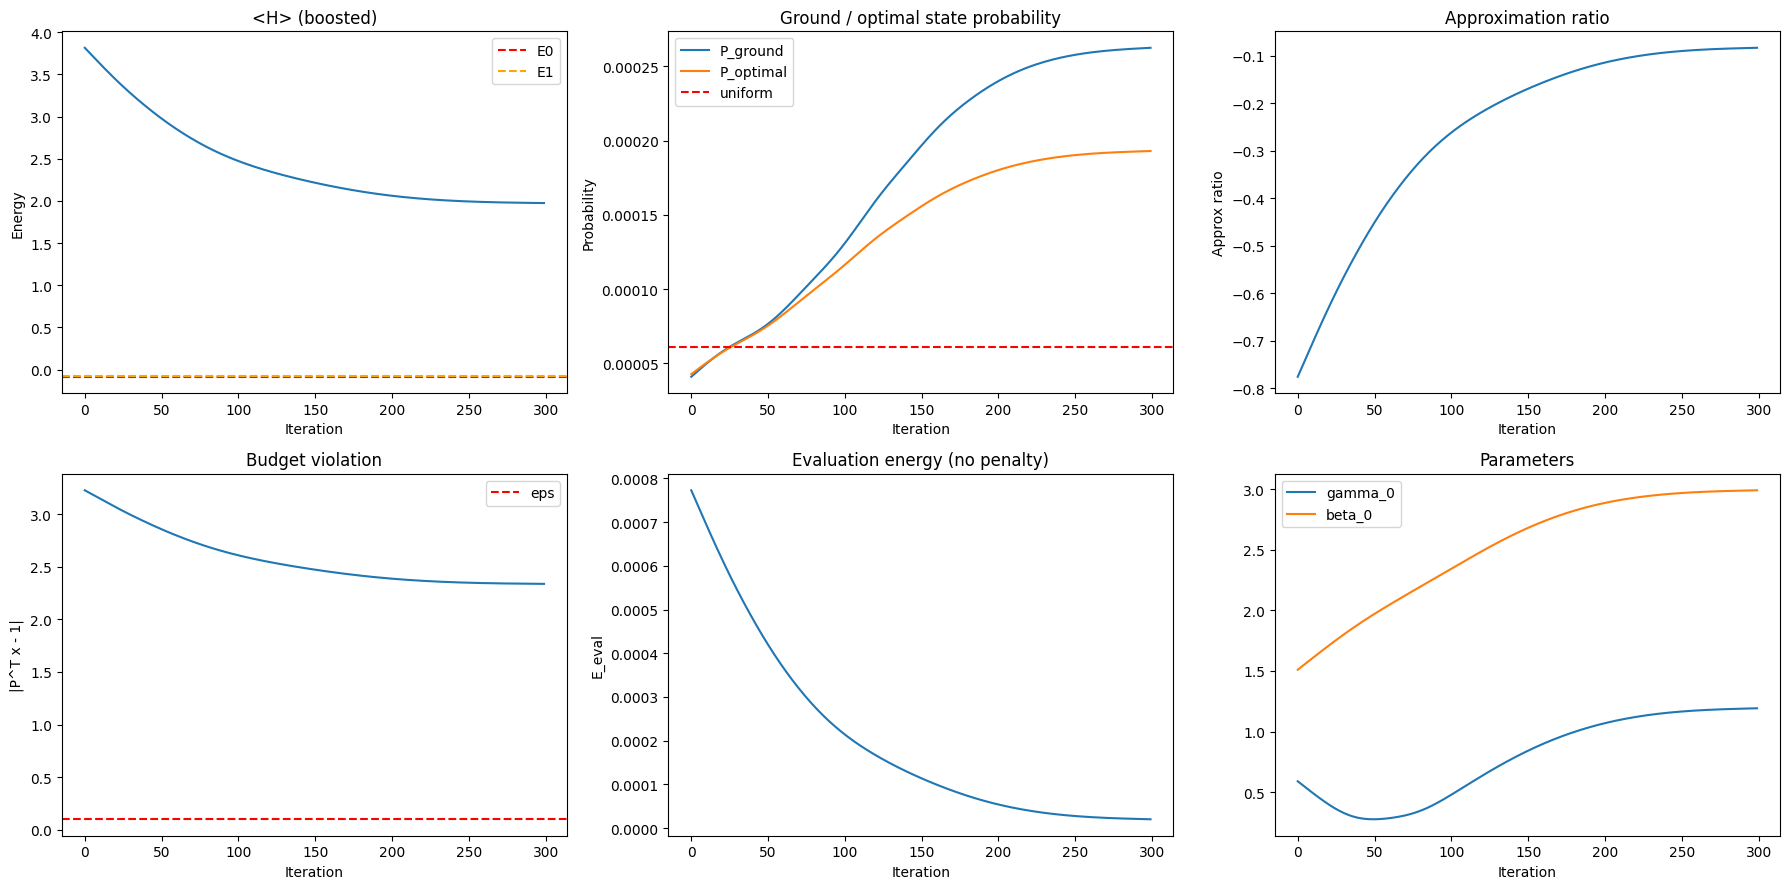

In [63]:
plt.figure(figsize=(18, 9))

plt.subplot(2, 3, 1)
plt.plot(history[:, 0] * hamiltonian_boost)
plt.axhline(y=E0, color="r", linestyle="--", label="E0")
plt.axhline(y=E1, color="orange", linestyle="--", label="E1")
plt.xlabel("Iteration"); plt.ylabel("Energy"); plt.title("<H> (boosted)"); plt.legend()

plt.subplot(2, 3, 2)
plt.plot(history[:, 3], label="P_ground")
plt.plot(history[:, 4], label="P_optimal")
plt.axhline(y=1 / dim, color="r", linestyle="--", label="uniform")
plt.xlabel("Iteration"); plt.ylabel("Probability"); plt.title("Ground / optimal state probability"); plt.legend()

plt.subplot(2, 3, 3)
plt.plot(history[:, 5])
plt.xlabel("Iteration"); plt.ylabel("Approx ratio"); plt.title("Approximation ratio")

plt.subplot(2, 3, 4)
plt.plot(np.sqrt(np.maximum(history[:, 2], 0.0) / lamb))
plt.axhline(y=eps, color="r", linestyle="--", label="eps")
plt.xlabel("Iteration"); plt.ylabel("|P^T x - 1|"); plt.title("Budget violation"); plt.legend()

plt.subplot(2, 3, 5)
plt.plot(history[:, 1])
plt.xlabel("Iteration"); plt.ylabel("E_eval"); plt.title("Evaluation energy (no penalty)")

plt.subplot(2, 3, 6)
plt.plot(history[:, 6], label="gamma_0")
plt.plot(history[:, 7], label="beta_0")
plt.xlabel("Iteration"); plt.title("Parameters"); plt.legend()

plt.tight_layout()
plt.show()

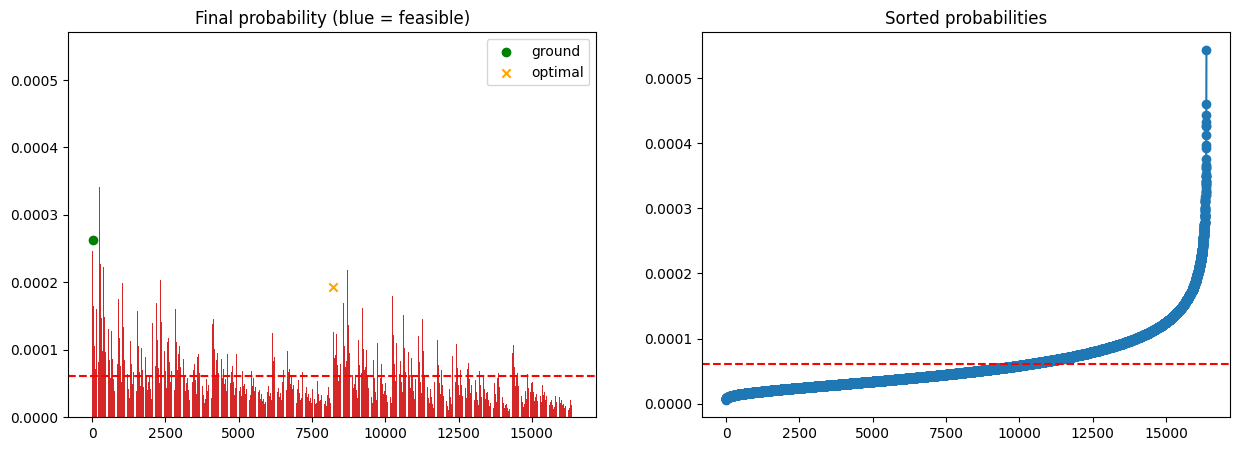

In [64]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
colors = np.where(np.isin(np.arange(dim), idx_feasible), "tab:blue", "tab:red")
plt.bar(np.arange(dim), prob, color=colors)
plt.scatter(idx_ground, prob[idx_ground], color="green", zorder=3, label="ground")
plt.scatter([idx_optimal], [prob[idx_optimal]], color="orange", marker="x", zorder=3, label="optimal")
plt.axhline(y=1 / dim, color="r", linestyle="--")
plt.title("Final probability (blue = feasible)"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(sorted(prob), marker="o")
plt.axhline(y=1 / dim, color="r", linestyle="--")
plt.title("Sorted probabilities")
plt.show()

In [65]:
assert False

AssertionError: 

# Method Comparison

Reuses the cached results written by `run()` (each config is optimized only if it has no saved run).


E 0.027325, E_eval 0.000020, P_gs 0.0003, LR 0.0003: 100%|██████████| 300/300 [00:37<00:00,  7.90it/s]
E 0.000460, E_eval -0.000538, P_gs 0.0030:  52%|█████▏    | 157/300 [00:04<00:04, 32.13it/s]


                     Run    Energy  Prob_Ground  Approx_ratio  epochs     time_s
0               gradient  1.974802     0.000262     -0.083723     300  37.990563
1  mcLachlan_diagonalize  0.060047     0.002894      0.435722      90   2.814250
2     mcLachlan_tikhonov  0.033121     0.002969      0.430311     158   4.900387


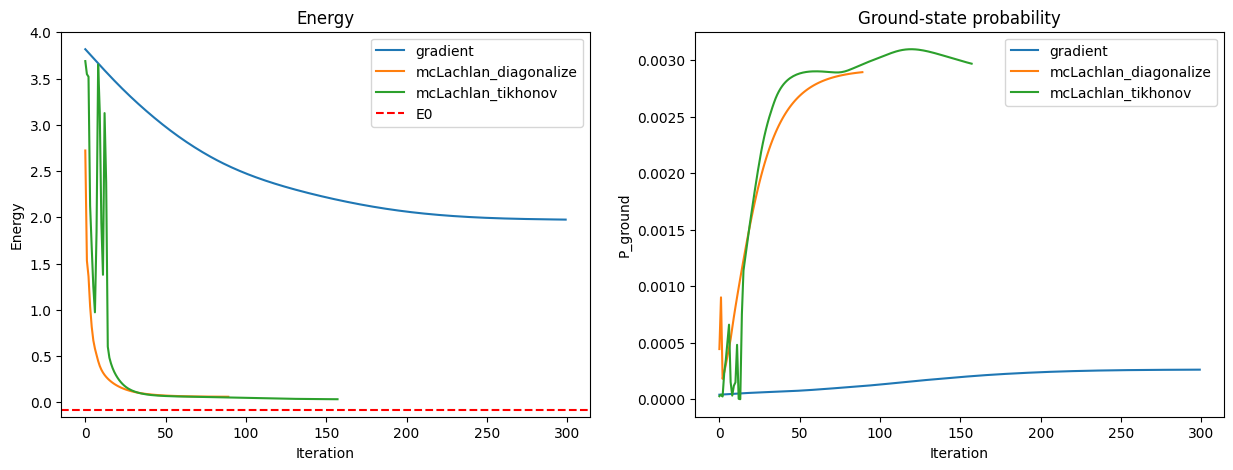

In [66]:
compare_configs = [("gradient", None), ("mcLachlan", "diagonalize"), ("mcLachlan", "tikhonov")]
runs = {}
for method, inv in compare_configs:
    r = run(method=method, inverse=inv, overwrite=False)
    runs[r["tag"]] = r

rows = [[name, r["history"][-1, 0] * hamiltonian_boost, r["history"][-1, 3], r["history"][-1, 5],
         r["num_iter"], r["optim_time"], r["iter_times"].mean() * 1e3, r["loaded"]]
        for name, r in runs.items()]
print(pd.DataFrame(rows, columns=["Run", "Energy", "Prob_Ground", "Approx_ratio", "epochs", "time_s", "iter_ms", "cached"]))

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
for name, r in runs.items():
    plt.plot(r["history"][:, 0] * hamiltonian_boost, label=name)
plt.axhline(y=E0, color="r", linestyle="--", label="E0")
plt.xlabel("Iteration"); plt.ylabel("Energy"); plt.title("Energy"); plt.legend()

plt.subplot(1, 2, 2)
for name, r in runs.items():
    plt.plot(r["history"][:, 3], label=name)
plt.xlabel("Iteration"); plt.ylabel("P_ground"); plt.title("Ground-state probability"); plt.legend()
plt.show()
